In [1]:
import os
import sys
import glob
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import ConcatDataset
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import GCNConv as gcn
from torch_geometric.nn import EdgeConv 
from torch_geometric.nn import DynamicEdgeConv 
from sklearn.metrics import roc_curve, auc

In [2]:
sys.path.append('modules') #direct to our module package
import architectures as arch

In [16]:
SEED = 2026
np.random.seed(SEED)    # Setting the seed for reproducibility
torch.manual_seed(SEED)

validation_directory = "/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all"
validation_paths = glob.glob(os.path.join(validation_directory, "v*"))
print(validation_paths)

['/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_50_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_5_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_100_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_10_graphs.pt', '/standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_enriched_merged.pt']


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
num_gpus = torch.cuda.device_count()

print("Beginning to load validation files")
val_file_list = []
for path in validation_paths:
    val_file_list.append((torch.load(path, weights_only = False)))
    print(f"Loaded: {path}")

Beginning to load validation files
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_50_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_5_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_100_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_signal_signal_10_graphs.pt
Loaded: /standard/ldmxuva/gnn_files/note_stuff/validation_graphs_all/validation_enriched_merged.pt


In [18]:
trained_model_state_dict_dynamic = torch.load('/standard/ldmxuva/gnn_files/run_output/dynamic_run_extended_best_model.pt', weights_only = True)
trained_model_state_dict_static = torch.load('/standard/ldmxuva/gnn_files/run_output/static_run_extended_best_model.pt', weights_only = True)
model_preloaded_dynamic = arch.GNN_v3_dynamic(in_channels = 4, 
                                     hc1 = 10, hc2 = 20, hc3 = 40, hc4 = 50, 
                                     fc1 = 25, fc2 = 12, fc3 = 6, 
                                     k1 = 33, k2 = 25, k3 = 17, k4 = 9,
                                     out_channels = 2)

model_preloaded_static = arch.GNN_v3_static(in_channels = 4, 
                                     hc1 = 10, hc2 = 20, hc3 = 40, hc4 = 50, 
                                     fc1 = 25, fc2 = 12, fc3 = 6, 
                                     out_channels = 2)

model_preloaded_static.load_state_dict(trained_model_state_dict_static)
model_preloaded_static = model_preloaded_static.to(device)
model_preloaded_static.eval()

model_preloaded_dynamic.load_state_dict(trained_model_state_dict_dynamic)
model_preloaded_dynamic = model_preloaded_dynamic.to(device)
model_preloaded_dynamic.eval()

GNN_v3_dynamic(
  (ECal_branch): DynamicEdgeConvBlock(
    (mlp1): Sequential(
      (0): Linear(in_features=8, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
    )
    (mlp2): Sequential(
      (0): Linear(in_features=20, out_features=20, bias=True)
      (1): ReLU()
      (2): Linear(in_features=20, out_features=20, bias=True)
    )
    (mlp3): Sequential(
      (0): Linear(in_features=40, out_features=40, bias=True)
      (1): ReLU()
      (2): Linear(in_features=40, out_features=40, bias=True)
    )
    (mlp4): Sequential(
      (0): Linear(in_features=80, out_features=50, bias=True)
      (1): ReLU()
      (2): Linear(in_features=50, out_features=50, bias=True)
    )
    (edgeconv1): DynamicEdgeConv(nn=Sequential(
      (0): Linear(in_features=8, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
    ), k=33)
    (edgeconv2): DynamicEdgeConv(nn=Sequential(
      (0

In [19]:
val_file_list[4] = [item for sublist in val_file_list[4] for item in sublist]

# Verify
print(type(val_file_list[4][0]))  # Should now be torch_geometric.data.data.Data

m100_bkgd_roc_sample = val_file_list[4]+val_file_list[2]

m100_roc_sample_loader = DataLoader(m100_bkgd_roc_sample, batch_size = 500, drop_last = True, shuffle=True, num_workers=1)

<class 'torch_geometric.data.data.Data'>


In [20]:
all_labels100 = []
for batch in m100_roc_sample_loader:
    all_labels100.append(batch.y)
all_labels100 = torch.cat(all_labels100)
torch.bincount(all_labels100)
print(f"Split -> bkgd {(torch.bincount(all_labels100))[0]}, m100 {(torch.bincount(all_labels100))[1]}")

Split -> bkgd 37548, m100 27952


In [23]:
y_scores_m100_dynamic = []
y_scores_m100_static = []
y_true_m100 = []

print(f"Using device: {device} ({num_gpus} GPUs available)")

with torch.no_grad():
    for data in m100_roc_sample_loader:
        # Move batch to GPU
        data = data.to(device)

        # Forward pass on GPU
        out_dynamic = model_preloaded_dynamic(data)
        out_static = model_preloaded_static(data)

        # Assuming binary classification and out shape [N, 2]
        probs_dynamic = torch.softmax(out_dynamic, dim=1)[:, 1]
        probs_static = torch.softmax(out_static, dim=1)[:,1]

        # Only CPU when appending
        y_scores_m100_dynamic.append(probs_dynamic.cpu())
        y_scores_m100_static.append(probs_static.cpu())
        y_true_m100.append(data.y.cpu())
    print("done!")


y_true_m100 = torch.cat(y_true_m100).numpy()
y_scores_m100_static = torch.cat(y_scores_m100_static).numpy()
y_scores_m100_dynamic = torch.cat(y_scores_m100_dynamic).numpy()

fpr100_s, tpr100_s, thresholds100_s = roc_curve(y_true_m100, y_scores_m100_static)
roc_auc_100_s = auc(fpr100_s, tpr100_s)

fpr100_d, tpr100_d, thresholds100_d = roc_curve(y_true_m100, y_scores_m100_dynamic)
roc_auc_100_d = auc(fpr100_d, tpr100_d)

Using device: cuda (1 GPUs available)
done!


In [29]:
#now load in the BDT stuff:
d = np.load('roc_mA_0100.npz')
fpr_b, tpr_b = d['fpr'], d['tpr']
roc_auc_100_b = auc(fpr_b, tpr_b)

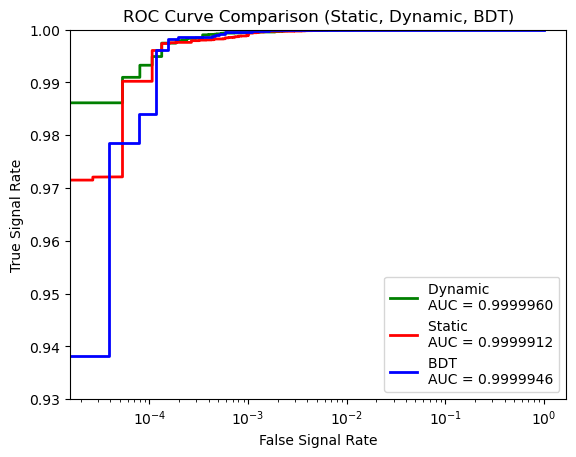

In [45]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr100_d, 
         tpr100_d, 
         color='green', 
         lw=2, 
         label=f'Dynamic \nAUC = {roc_auc_100_d:.7f}')
plt.plot(fpr100_s, 
         tpr100_s, 
         color='red', 
         lw=2, 
         label=f'Static \nAUC = {roc_auc_100_s:.7f}')
plt.plot(fpr_b, 
         tpr_b, 
         color='blue', 
         lw=2, 
         label=f'BDT \nAUC = {roc_auc_100_b:.7f}')
#plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
#plt.xlim([-0.00001, 0.001])
#plt.xlim([0,0.1])
plt.xscale('log')
plt.ylim([0.93, 1])
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('ROC Curve Comparison (Static, Dynamic, BDT)')
plt.legend(loc="lower right")
plt.savefig("comparison_roc.png")
plt.savefig("comparison_roc.pdf")